**Time Series Analysis**
Visualizing ACF & PCF
Autocorrelation function & Partial Autocorrelation function for specific stock, in this case The Hartford

In [57]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
register_matplotlib_converters()

In [4]:
#defining ticker symbol to get stock price
tickerSymbol = "HIG"

In [30]:
#gathering ticker data
tickerData = yf.Ticker(tickerSymbol)

In [31]:
# retrieving historical data from 2010 to 2026
tickerDF = tickerData.history(start='2010-1-1', end='2026-1-1')

In [ ]:
tickerDF = tickerDF [['Close']]

In [13]:
tickerDF.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-01-04 00:00:00-05:00,17.228221,17.409877,17.082897,17.337215,6944100,0.0,0.0
2010-01-05 00:00:00-05:00,17.242757,18.710536,17.199160,18.666939,12424000,0.0,0.0
2010-01-06 00:00:00-05:00,18.536153,19.168314,18.230971,18.979393,10690200,0.0,0.0
2010-01-07 00:00:00-05:00,18.892193,19.415360,18.761400,19.270037,7033600,0.0,0.0
2010-01-08 00:00:00-05:00,19.175579,19.306372,18.725074,19.052053,5130500,0.0,0.0


Notice the data is not stationary (not constant), there is an upward trend throughout throughout the years from 2010 to 2026. As a result we can plot the stock price one day minus stock price on previous day

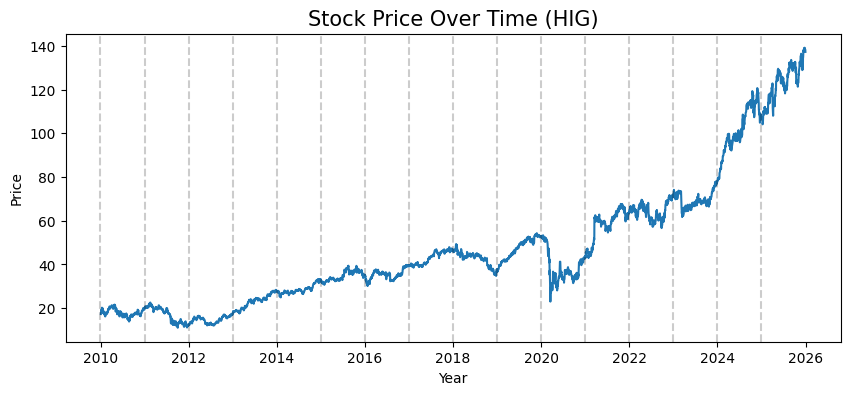

In [42]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(10,4))
plt.plot(tickerDF.Close)
plt.title('Stock Price Over Time (%s)'%tickerSymbol, fontsize= 15)
plt.ylabel('Price', fontsize= 10)
plt.xlabel('Year', fontsize= 10)
for year in range(2010,2026):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)



In [54]:
#stock price tomorrow minus stock price today
first_difference = tickerDF.Close.values[1:] - tickerDF.Close.values[:-1]
#Appending 0 to restore array length so it matches the original dataset size
first_difference = np.concatenate([first_difference, [0]])
tickerDF['FirstDifference'] = first_difference
tickerDF.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,First Difference,FirstDifference
Date,,,,,,,,,
2010-01-04 00:00:00-05:00,17.228221,17.409877,17.082897,17.337215,6944100,0.0,0.0,1.329723,1.329723
2010-01-05 00:00:00-05:00,17.242757,18.710536,17.199160,18.666939,12424000,0.0,0.0,0.312454,0.312454
2010-01-06 00:00:00-05:00,18.536153,19.168314,18.230971,18.979393,10690200,0.0,0.0,0.290644,0.290644
2010-01-07 00:00:00-05:00,18.892193,19.415360,18.761400,19.270037,7033600,0.0,0.0,-0.217983,-0.217983
2010-01-08 00:00:00-05:00,19.175579,19.306372,18.725074,19.052053,5130500,0.0,0.0,-0.036343,-0.036343


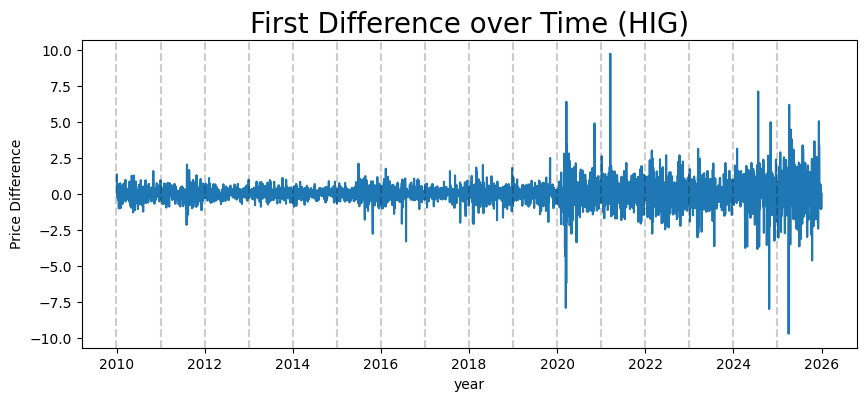

In [55]:
plt.figure(figsize=(10,4))
plt.plot(tickerDF.FirstDifference)
plt.title('First Difference over Time (%s)'%tickerSymbol, fontsize=20)
plt.ylabel('Price Difference', fontsize=10)
plt.xlabel('year', fontsize=10)
for year in range(2010,2026):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

Time Series: Autocorrelation Function plot

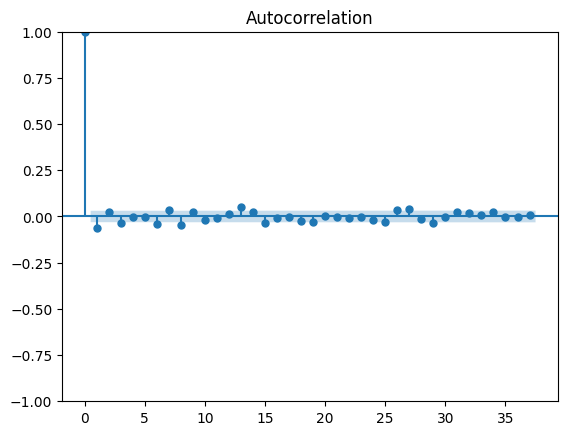

In [58]:
acf_plot = plot_acf(tickerDF.FirstDifference)

Partial Autocorrelation Function

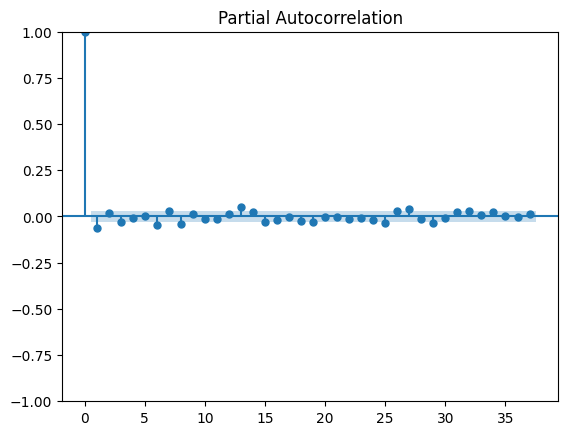

In [62]:
pacf_plot = plot_pacf(tickerDF.FirstDifference)

A few predictive lags are present, for example at 1, but overall there is limited visible predictive power to build a model.